In [13]:
import tensorflow as tf
import numpy as np

In [14]:
data = np.loadtxt('stock_volat_curated.csv', delimiter=',')

data = data.T
np.random.shuffle(data)
data = data.T

X = data[:505,:]
Y = data[-1:,:] # Using volatility now

print(X.shape)
print(Y.shape)

(505, 6963)
(1, 6963)


In [15]:
print("Volatility Stats:")
std_Y = Y.std()
print("Standard Deviation:", std_Y)
print("Variance:", std_Y ** 2)
print("Second standard Deviation:", 2 * std_Y)

Volatility Stats:
Standard Deviation: 0.368920205373167
Variance: 0.1361021179325797
Second standard Deviation: 0.737840410746334


In [21]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(505,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(126, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanAbsoluteError(),
    metrics=['mae']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 252)            │       127,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 126)            │        31,878 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,053 (1.11 MB)

 Trainable params: 288,541 (1.10 MB)

 Non-trainable params: 1,512 (5.91 KB)

In [22]:
# Clip extreme outliers in Y so MSE isn't dominated by rare spikes
# (p99 ≈ 2.09, but max ≈ 19 — those few outliers monopolize the gradient)
#y_lo = np.percentile(Y, 1)
#y_hi = np.percentile(Y, 99)
#print(f"Clipping Y to [{y_lo:.4f}, {y_hi:.4f}]  (was [{Y.min():.4f}, {Y.max():.4f}])")
#Y = np.clip(Y, y_lo, y_hi)

In [23]:
train_ratio = 0.8
train_size = int(X.shape[1] * train_ratio)

X_train = X[:,:train_size].T
Y_train = Y[:,:train_size].T

X_val = X[:,train_size:].T
Y_val = Y[:,train_size:].T

print(X_train.shape)
print(X_val.shape)

(5570, 505)
(1393, 505)


In [24]:
# Normalize features
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0) + 1e-8
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std

# Normalize Y — without this the output layer fights a non-zero offset
# and the model collapses to predicting the mean/median
#y_mean = Y_train.mean()
#y_std  = Y_train.std() + 1e-8
#Y_train_norm = (Y_train - y_mean) / y_std
#Y_val_norm   = (Y_val   - y_mean) / y_std
#print(f"Y normalized: mean→0, std→1  (y_mean={y_mean:.4f}, y_std={y_std:.4f})")


In [25]:
model.fit(X_train, Y_train,
                  validation_data=(X_val, Y_val),
                  batch_size=64, 
                  epochs=100,
                  verbose=1,
                  shuffle=True)


Epoch 1/100


88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2396 - mae: 0.2294 - val_loss: 0.2011 - val_mae: 0.1908
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1970 - mae: 0.1867 - val_loss: 0.1926 - val_mae: 0.1822
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1790 - mae: 0.1685 - val_loss: 0.1794 - val_mae: 0.1688
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1682 - mae: 0.1576 - val_loss: 0.1736 - val_mae: 0.1629
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1591 - mae: 0.1484 - val_loss: 0.1686 - val_mae: 0.1578
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1530 - mae: 0.1421 - val_loss: 0.1638 - val_mae: 0.1528
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1488 - mae: 0.1377 - val_loss: 0.1635 - val_mae: 0.1524
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1431 - mae: 0.1320 - val_loss: 0.1589 - val_mae: 0.1477
Epoch 9/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1382 - mae: 0.1

In [26]:
import matplotlib.pyplot as plt

def plot_acc_and_loss(history, title):
    plt.title("Model and Validation MAE for " + title)
    xs = list(range(1, len(history.history['mae']) + 1))
    plt.plot(xs, history.history['mae'], label="Model MAE", color="Red")
    plt.plot(xs, history.history['val_mae'], label="Validation MAE", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.show()

    plt.title("Model and Validation Loss for " + title)
    xs = list(range(1, len(history.history['val_loss']) + 1))
    plt.plot(xs, history.history['loss'], label="Model loss", color="Red")
    plt.plot(xs, history.history['val_loss'], label="Validation loss", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.legend()
    plt.show()

def prcnt_within_tolerance(x, y, model, tolerance):
    print("Count:",np.count_nonzero(abs(model.predict(x) - y) <= tolerance))
    print("X Len:", x.shape[0])
    return np.count_nonzero(abs(model.predict(x) - y) <= tolerance) / x.shape[0]

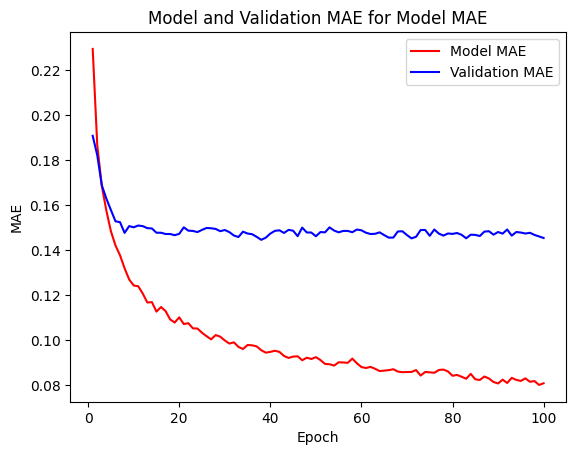

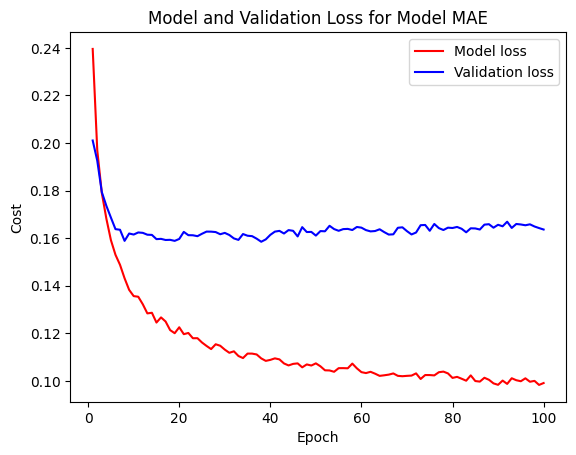

In [27]:
plot_acc_and_loss(model.history, "Model MAE")

In [28]:
print("Prediction:", model.predict(X_train[:15]))
print("Label:", Y_train[:15])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction: [[0.97162116]
 [0.41449696]
 [0.719352  ]
 [0.24816573]
 [0.19168337]
 [0.14930198]
 [0.24688384]
 [0.67719835]
 [0.49331877]
 [0.13513777]
 [0.23174316]
 [0.17602102]
 [0.3918897 ]
 [0.24436794]
 [0.741582  ]]
Label: [[2.1693314 ]
 [0.37306934]
 [0.63326719]
 [0.22520022]
 [0.19465268]
 [0.18349252]
 [0.23023005]
 [0.63321114]
 [0.44066745]
 [0.12328233]
 [0.21407227]
 [0.17422759]
 [0.35818474]
 [0.29292867]
 [0.67773797]]


In [29]:
print("Prediction:", model.predict(X_val[:15]))
print("Label:", Y_val[:15])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Prediction: [[0.34689358]
 [0.30358785]
 [0.27662757]
 [0.43618342]
 [0.6626513 ]
 [0.37164858]
 [0.28031182]
 [0.20105816]
 [0.18748507]
 [0.5532828 ]
 [0.16787115]
 [0.27416247]
 [0.25113985]
 [0.23712514]
 [0.521409  ]]
Label: [[0.25744044]
 [0.15473998]
 [0.24199412]
 [0.36881111]
 [0.82224596]
 [0.23816103]
 [0.17502474]
 [0.54143589]
 [0.24276259]
 [0.70217943]
 [0.16123436]
 [0.21644893]
 [0.30463426]
 [0.26196526]
 [0.32849336]]


In [31]:
modelMSE = tf.keras.Sequential([
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(505,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(126, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

modelMSE.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mae']
)

modelMSE.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 252)            │       127,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 126)            │        31,878 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │           127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,053 (1.11 MB)

 Trainable params: 288,541 (1.10 MB)

 Non-trainable params: 1,512 (5.91 KB)

In [32]:
modelMSE.fit(X_train, Y_train,
                  validation_data=(X_val, Y_val),
                  batch_size=64, 
                  epochs=100,
                  verbose=1,
                  shuffle=True)

Epoch 1/100


88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1614 - mae: 0.2397 - val_loss: 0.1367 - val_mae: 0.1870
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1245 - mae: 0.2021 - val_loss: 0.1296 - val_mae: 0.1885
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1054 - mae: 0.1765 - val_loss: 0.1195 - val_mae: 0.1736
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0961 - mae: 0.1626 - val_loss: 0.1155 - val_mae: 0.1700
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0903 - mae: 0.1531 - val_loss: 0.1134 - val_mae: 0.1672
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0873 - mae: 0.1469 - val_loss: 0.1096 - val_mae: 0.1626
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0854 - mae: 0.1429 - val_loss: 0.1089 - val_mae: 0.1653
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0833 - mae: 0.1389 - val_loss: 0.1092 - val_mae: 0.1663
Epoch 9/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0806 - mae: 0.1

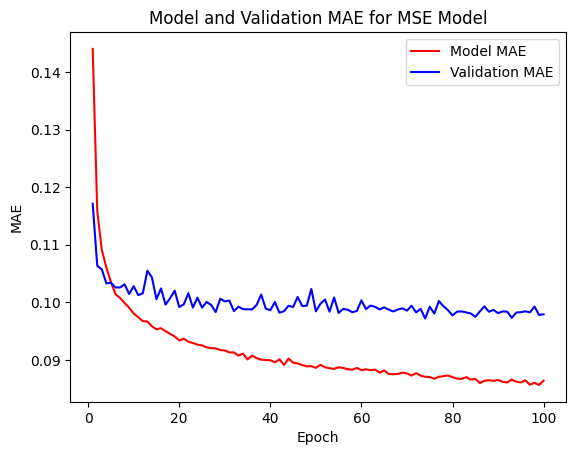

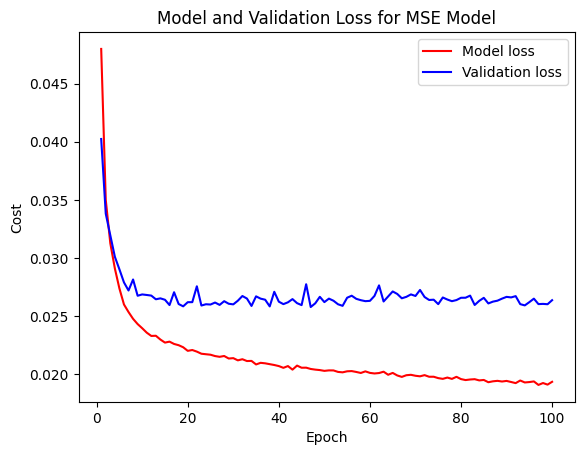

In [20]:
plot_acc_and_loss(modelMSE.history, "MSE Model")

In [22]:
print("Prediction:", modelMSE.predict(X_val[:15]))
print("Label:", Y_val[:15])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Prediction: [[0.4224567 ]
 [0.43945193]
 [0.8156959 ]
 [0.41976762]
 [0.4713973 ]
 [0.27980185]
 [0.46031892]
 [0.23522657]
 [0.53443605]
 [0.4725278 ]
 [0.52662945]
 [0.3980764 ]
 [0.55976367]
 [0.24570915]
 [0.48594615]]
Label: [[0.75532502]
 [0.38441765]
 [0.55014361]
 [0.48599805]
 [0.3672867 ]
 [0.32232112]
 [0.60535651]
 [0.20157432]
 [0.43298318]
 [0.58553345]
 [0.47157946]
 [0.70732775]
 [0.67770412]
 [0.22819325]
 [0.36198085]]


In [23]:
print("Hubard Within 5%:", prcnt_within_tolerance(X_val, Y_val, model, 0.05))
print("Hubard Within 10%:", prcnt_within_tolerance(X_val, Y_val, model, 0.1))
print("Hubard Within 20%:", prcnt_within_tolerance(X_val, Y_val, model, 0.2))

  1/465 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
Count: 2022
X Len: 14878
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step
Hubard Within 5%: 0.13590536362414302
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step
Count: 4005
X Len: 14878
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step
Hubard Within 10%: 0.2691894071783842
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
Count: 7936
X Len: 14878
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step
Hubard Within 20%: 0.5334050275574674


In [24]:
print("MSE Within 5%:", prcnt_within_tolerance(X_val, Y_val, modelMSE, 0.05))
print("MSE Within 10%:", prcnt_within_tolerance(X_val, Y_val, modelMSE, 0.1))
print("MSE Within 20%:", prcnt_within_tolerance(X_val, Y_val, modelMSE, 0.2))

465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step
Count: 5880
X Len: 14878
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step
MSE Within 5%: 0.39521441053905093
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step
Count: 10085
X Len: 14878
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step
MSE Within 10%: 0.6778464847425729
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step
Count: 13017
X Len: 14878
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step
MSE Within 20%: 0.8749159833310929


In [25]:
modelWD = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(252,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1024, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

modelWD.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mae']
)

modelWD.summary()

/home/aus/Code/school/3ML3-Final/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1024)           │       259,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,889 (5.03 MB)

 Trainable params: 1,313,793 (5.01 MB)

 Non-trainable params: 4,096 (16.00 KB)

In [26]:
modelWD.fit(X_train, Y_train,
                  validation_data=(X_val, Y_val),
                  batch_size=64, 
                  epochs=100,
                  verbose=1,
                  shuffle=True)

Epoch 1/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0794 - mae: 0.1801 - val_loss: 0.0463 - val_mae: 0.1218
Epoch 2/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0398 - mae: 0.1165 - val_loss: 0.0383 - val_mae: 0.1102
Epoch 3/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0356 - mae: 0.1108 - val_loss: 0.0352 - val_mae: 0.1065
Epoch 4/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0333 - mae: 0.1070 - val_loss: 0.0342 - val_mae: 0.1090
Epoch 5/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0322 - mae: 0.1042 - val_loss: 0.0348 - val_mae: 0.1066
Epoch 6/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0320 - mae: 0.1029 - val_loss: 0.0349 - val_mae: 0.1035
Epoch 7/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0313 - mae: 0.1013 - val_loss: 0.0338 - val_mae: 0.1039
Epoch 8/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0306 - mae: 0.1007 - val_loss: 0.0331 - val_mae: 0.1030
Epoch 9/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 6s 6m

In [8]:
modelLSTM = tf.keras.Sequential([
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(252,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Reshape((252,1)),
    tf.keras.layers.LSTM(units=10, input_shape=(252,), return_sequences=False),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

modelLSTM.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanAbsoluteError(),
    metrics=['mae']
)

modelLSTM.summary()

/home/aus/Code/school/3ML3-Final/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 252, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,255 (254.90 KB)

 Trainable params: 64,751 (252.93 KB)

 Non-trainable params: 504 (1.97 KB)

In [31]:
print("WD Within 5%:", prcnt_within_tolerance(X_val, Y_val, modelWD, 0.05))
print("WD Within 10%:", prcnt_within_tolerance(X_val, Y_val, modelWD, 0.1))
print("WD Within 20%:", prcnt_within_tolerance(X_val, Y_val, modelWD, 0.2))

465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step
Count: 5755
X Len: 14878
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step
WD Within 5%: 0.38681274364833984
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step
Count: 10045
X Len: 14878
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step
WD Within 10%: 0.6751579513375454
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step
Count: 13043
X Len: 14878
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step
WD Within 20%: 0.8766635300443608


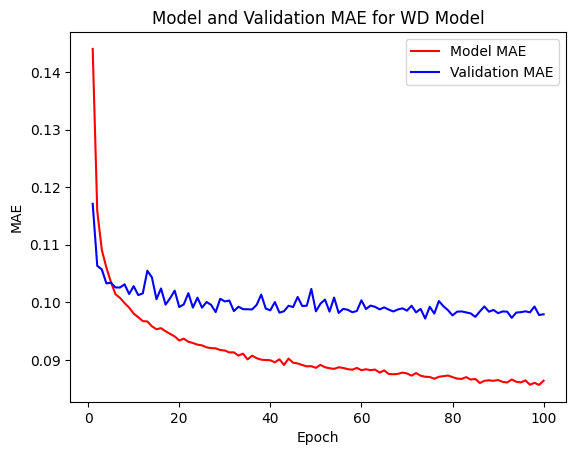

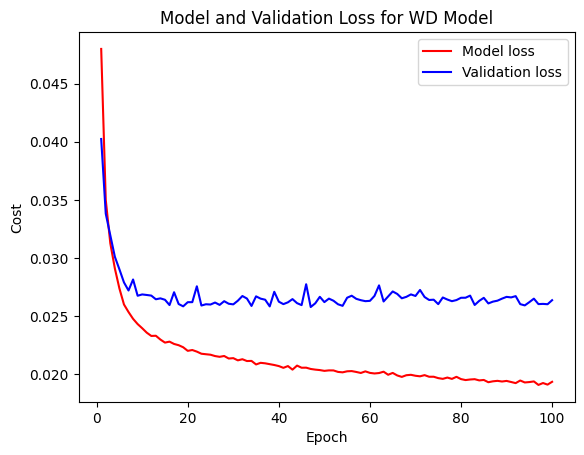

In [28]:
plot_acc_and_loss(modelMSE.history, "WD Model")

In [9]:
modelLSTM.fit(X_train, Y_train,
                  validation_data=(X_val, Y_val),
                  batch_size=64, 
                  epochs=100,
                  verbose=1,
                  shuffle=True)


Epoch 1/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - loss: 0.1162 - mae: 0.1153 - val_loss: 0.1184 - val_mae: 0.1173
Epoch 2/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 0.1041 - mae: 0.1026 - val_loss: 0.1122 - val_mae: 0.1104
Epoch 3/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - loss: 0.0999 - mae: 0.0979 - val_loss: 0.1164 - val_mae: 0.1142
Epoch 4/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 0.0980 - mae: 0.0957 - val_loss: 0.1081 - val_mae: 0.1057
Epoch 5/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 0.0964 - mae: 0.0939 - val_loss: 0.1068 - val_mae: 0.1041
Epoch 6/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 0.0951 - mae: 0.0923 - val_loss: 0.1107 - val_mae: 0.1078
Epoch 7/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 0.0946 - mae: 0.0916 - val_loss: 0.1105 - val_mae: 0.1074
Epoch 8/100
930/930 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 0.0941 - mae: 0.0909 - val_loss: 0.1100 - val_mae: 0.1067
Epoch 9/100
930/930 ━━━━━━━━━━━━

KeyboardInterrupt: 